In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv('iris.csv')

In [3]:
data

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [4]:
data.isnull()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [5]:
feature_cols = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width']
X = data[feature_cols].values.astype(float)

classes = sorted(data['variety'].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
y_idx = data['variety'].map(class_to_idx).values

y = np.zeros((len(y_idx), len(classes)))
y[np.arange(len(y_idx)), y_idx] = 1.0

print('Classes (in order):', classes)
print('Example one-hot rows:')
print(y[:5])

Classes (in order): ['Setosa', 'Versicolor', 'Virginica']
Example one-hot rows:
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [6]:
n = len(X)
perm = np.random.permutation(n)
X = X[perm]
y = y[perm]

In [7]:
n_train = int(n * 0.7)
n_val = int(n * 0.15)
# remaining ~15% becomes the test set

X_train_raw = X[:n_train]
mean = X_train_raw.mean(axis=0)
std = X_train_raw.std(axis=0)
X_std = (X - mean) / std

X_train, y_train = X_std[:n_train], y[:n_train]
X_val, y_val = X_std[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test, y_test = X_std[n_train+n_val:], y[n_train+n_val:]

print('train/val/test sizes:', len(X_train), len(X_val), len(X_test))
print('train class balance:', y_train.sum(axis=0))
print('val class balance:  ', y_val.sum(axis=0))
print('test class balance: ', y_test.sum(axis=0))

train/val/test sizes: 105 22 23
train class balance: [34. 35. 36.]
val class balance:   [7. 9. 6.]
test class balance:  [9. 6. 8.]


In [8]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    # subtracting the row-max before exponentiating avoids overflow for large numbers
    z = x - np.max(x, axis=1, keepdims=True)
    ex = np.exp(z)
    return ex / np.sum(ex, axis=1, keepdims=True)

In [9]:
n_features = X_train.shape[1]
n_hidden1 = 8
n_hidden2 = 8
n_classes = y_train.shape[1]

epochs = 3000
learnrate = 0.05

w1 = np.random.normal(scale=1/n_features**0.5, size=(n_features, n_hidden1))
b1 = np.zeros(n_hidden1)

w2 = np.random.normal(scale=1/n_hidden1**0.5, size=(n_hidden1, n_hidden2))
b2 = np.zeros(n_hidden2)

w3 = np.random.normal(scale=1/n_hidden2**0.5, size=(n_hidden2, n_classes))
b3 = np.zeros(n_classes)

In [10]:
def forward(X):
    h1_in = X.dot(w1) + b1
    h1_out = sigmoid(h1_in)

    h2_in = h1_out.dot(w2) + b2
    h2_out = sigmoid(h2_in)

    out_in = h2_out.dot(w3) + b3
    out = softmax(out_in)

    return h1_out, h2_out, out

def accuracy(X, y_true):
    _, _, out = forward(X)
    preds = np.argmax(out, axis=1)
    trues = np.argmax(y_true, axis=1)
    return np.mean(preds == trues)

def cross_entropy_loss(pred, true):
    eps = 1e-9  # avoids log(0)
    return -np.mean(np.sum(true * np.log(pred + eps), axis=1))

In [11]:
n_records = X_train.shape[0]
train_losses = []
val_accs = []

for e in range(epochs):
    # ---- forward pass ----
    h1_out, h2_out, out = forward(X_train)

    # ---- backward pass ----
    output_error_term = y_train - out                      # (n, n_classes)

    hidden2_error = output_error_term.dot(w3.T)
    hidden2_error_term = hidden2_error * h2_out * (1 - h2_out)

    hidden1_error = hidden2_error_term.dot(w2.T)
    hidden1_error_term = hidden1_error * h1_out * (1 - h1_out)

    dw3 = h2_out.T.dot(output_error_term) / n_records
    db3 = output_error_term.mean(axis=0)

    dw2 = h1_out.T.dot(hidden2_error_term) / n_records
    db2 = hidden2_error_term.mean(axis=0)

    dw1 = X_train.T.dot(hidden1_error_term) / n_records
    db1 = hidden1_error_term.mean(axis=0)

    # ---- weight updates: multiplication everywhere, no +/- typos ----
    w3 += learnrate * dw3
    b3 += learnrate * db3
    w2 += learnrate * dw2
    b2 += learnrate * db2
    w1 += learnrate * dw1
    b1 += learnrate * db1

    # ---- periodic monitoring ----
    if e % (epochs // 10) == 0 or e == epochs - 1:
        _, _, train_out = forward(X_train)
        train_loss = cross_entropy_loss(train_out, y_train)
        train_acc = accuracy(X_train, y_train)
        val_acc = accuracy(X_val, y_val)
        train_losses.append((e, train_loss))
        val_accs.append((e, val_acc))
        print(f'Epoch {e:4d}  train_loss={train_loss:.4f}  '
              f'train_acc={train_acc:.3f}  val_acc={val_acc:.3f}')

Epoch    0  train_loss=1.4517  train_acc=0.343  val_acc=0.273
Epoch  300  train_loss=0.8033  train_acc=0.810  val_acc=0.773
Epoch  600  train_loss=0.5083  train_acc=0.876  val_acc=0.773
Epoch  900  train_loss=0.3979  train_acc=0.933  val_acc=0.773
Epoch 1200  train_loss=0.3203  train_acc=0.943  val_acc=0.773
Epoch 1500  train_loss=0.2549  train_acc=0.971  val_acc=0.864
Epoch 1800  train_loss=0.2019  train_acc=0.981  val_acc=0.864
Epoch 2100  train_loss=0.1625  train_acc=0.981  val_acc=0.909
Epoch 2400  train_loss=0.1346  train_acc=0.981  val_acc=0.909
Epoch 2700  train_loss=0.1149  train_acc=0.981  val_acc=0.909
Epoch 2999  train_loss=0.1007  train_acc=0.981  val_acc=0.909


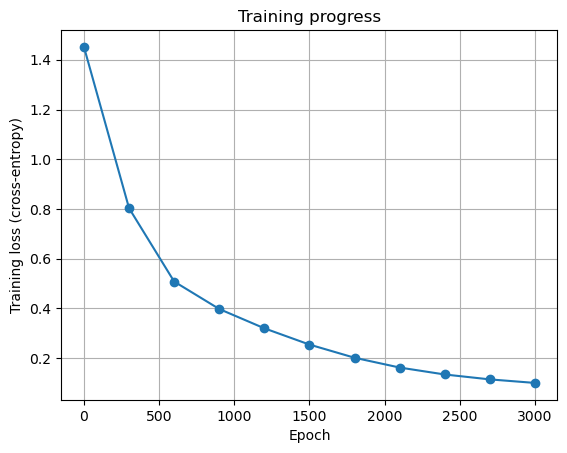

In [12]:
epochs_plotted, losses_plotted = zip(*train_losses)
plt.plot(epochs_plotted, losses_plotted, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training loss (cross-entropy)')
plt.title('Training progress')
plt.grid(True)
plt.savefig('training_loss.png')
plt.show()

In [13]:
test_acc = accuracy(X_test, y_test)
print(f'Final test accuracy: {test_acc:.3f}')

# A quick look at a few individual predictions
_, _, test_out = forward(X_test)
predicted_idx = np.argmax(test_out, axis=1)
true_idx = np.argmax(y_test, axis=1)

for i in range(10):
    pred_name = classes[predicted_idx[i]]
    true_name = classes[true_idx[i]]
    mark = 'correct' if pred_name == true_name else 'WRONG'
    print(f'Predicted: {pred_name:11s}  Actual: {true_name:11s}  [{mark}]')

Final test accuracy: 0.957
Predicted: Versicolor   Actual: Versicolor   [correct]
Predicted: Virginica    Actual: Virginica    [correct]
Predicted: Versicolor   Actual: Versicolor   [correct]
Predicted: Setosa       Actual: Setosa       [correct]
Predicted: Virginica    Actual: Virginica    [correct]
Predicted: Versicolor   Actual: Versicolor   [correct]
Predicted: Virginica    Actual: Virginica    [correct]
Predicted: Setosa       Actual: Setosa       [correct]
Predicted: Versicolor   Actual: Versicolor   [correct]
Predicted: Setosa       Actual: Setosa       [correct]
